
#### Introduction to SQL-Based Exploratory Analysis

Structured Query Language (SQL) is the standard tool for relational database management and analytical queries, widely adopted in data science for flexible, efficient exploration and summarization of tabular data (Date, 2004; Ramakrishnan & Gehrke, 2002). In the context of credit risk modeling, SQL enables rapid extraction of insights and descriptive statistics that are otherwise laborious to compute using procedural code alone (McKinney, 2017). The use of SQL facilitates reproducibility, transparency, and traceability, as each query acts as a precise, declarative statement of the analytical intent.

This study includes a dedicated SQL analysis section to demonstrate the power and practicality of combining classical database techniques with modern data science workflows. By formulating and answering ten domain-relevant questions using SQL, the analysis complements machine learning and statistical methods, providing business-friendly summaries of client characteristics, risk distributions, and feature interactions. This approach supports not only efficient hypothesis generation but also effective communication with non-technical stakeholders and auditability of the data pipeline (Cattell, 2011; van der Aalst et al., 2011).

In this project, the SQL-based analysis was implemented using the lightweight and widely adopted SQLite3 engine, which offers seamless integration with Python via the sqlite3 library and enables efficient querying of local datasets without the overhead of a full-scale database server (Owens, 2010).

Owens, M. (2010). The Definitive Guide to SQLite. Apress.



References:

Date, C.J. (2004). An Introduction to Database Systems (8th Edition). Pearson.
Ramakrishnan, R., & Gehrke, J. (2002). Database Management Systems (3rd Edition). McGraw-Hill.
McKinney, W. (2017). Python for Data Analysis (2nd Edition). O'Reilly Media.
Cattell, R. (2011). Scalable SQL and NoSQL Data Stores. ACM SIGMOD Record, 39(4), 12-27.
van der Aalst, W.M.P., et al. (2011). Process Mining: Overview and Outlook of Petri Net Analysis. Lecture Notes in Computer Science, 3080, 1-22.

##### Credit Risk SQL EDA: 10 Key Business Questions

This notebook demonstrates how to use SQL queries (via SQLite & Pandas) to answer business-relevant questions for credit risk assessment.


In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("df_clients_cleaned.csv")

# Create SQLite in-memory database and table
conn = sqlite3.connect(":memory:")
df.to_sql("clients", conn, index=False, if_exists="replace")


34455

##### Question 1: Distribution of Clients by Credit Risk Class

,Risk_Level,client_count
0,0,30434
1,1,3745
2,2,276


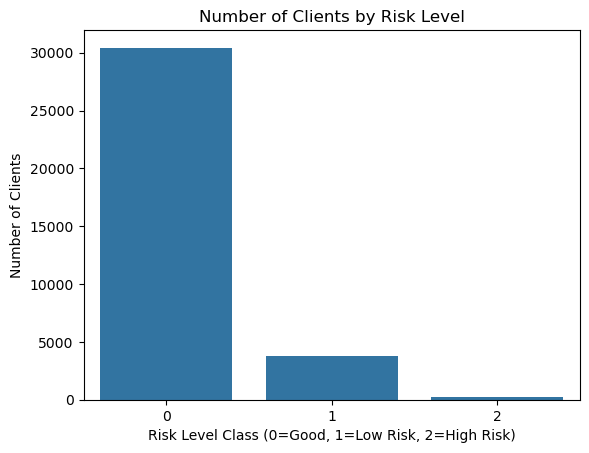

In [4]:
query = """
SELECT Risk_Level, COUNT(*) as client_count
FROM clients
GROUP BY Risk_Level
"""
risk_dist = pd.read_sql(query, conn)
display(risk_dist)

# Plot
sns.barplot(x='Risk_Level', y='client_count', data=risk_dist)
plt.title("Number of Clients by Risk Level")
plt.xlabel("Risk Level Class (0=Good, 1=Low Risk, 2=High Risk)")
plt.ylabel("Number of Clients")
plt.show()



The dataset is highly imbalanced with respect to the credit risk classification. The majority of clients (30,434) were labeled as Risk_Level 0 (Good Clients), indicating a low risk of default. A smaller segment, 3,745 clients, were classified as Risk_Level 1 (Low Risk), while only 276 clients were categorized as Risk_Level 2 (High Risk). This class imbalance is typical in credit risk datasets and highlights the importance of using appropriate modeling and evaluation techniques to ensure fair and robust predictions, especially for the rare high-risk group.



##### Question 2: Average & Median Income per Risk Class

In [6]:
# SQLite doesn't have MEDIAN by default, so I will use Pandas for median after query
query = """
SELECT Risk_Level, AVG(Income) AS avg_income
FROM clients
GROUP BY Risk_Level
"""
avg_income = pd.read_sql(query, conn)
median_income = df.groupby("Risk_Level")["Income"].median().reset_index(name="median_income")
income_stats = avg_income.merge(median_income, on="Risk_Level")
display(income_stats)


,Risk_Level,avg_income,median_income
0,0,172609.990701,157500.0
1,1,175641.494660,157500.0
2,2,171414.130435,162000.0


The average and median income levels are remarkably similar across all credit risk classes. Good Clients (Risk_Level 0) and Low Risk (Risk_Level 1) groups both have a median income of 157,500, while the High Risk group (Risk_Level 2) shows a slightly higher median income of 162,000. The average income values are also closely clustered, ranging from approximately 171,400 to 175,600. These results indicate that income alone does not strongly differentiate risk categories in this dataset, and other factors are likely more significant in the model’s classification of credit risk.



Question 3: Property Ownership vs Credit Risk


,Owns_Property,Risk_Level,count
0,N,0,9935
1,N,1,1374
2,N,2,111
3,Y,0,20499
4,Y,1,2371
5,Y,2,165


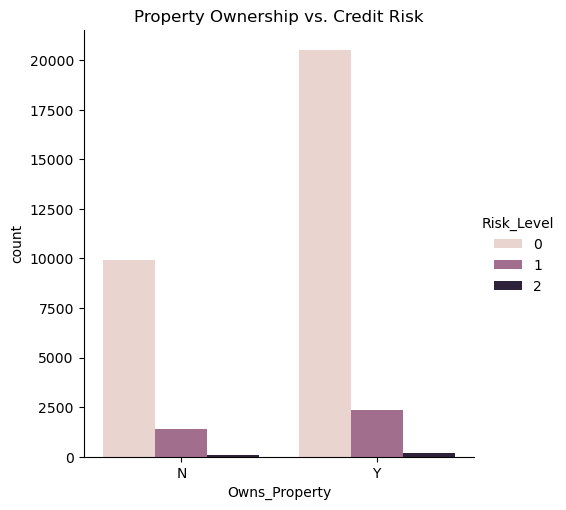

In [7]:
query = """
SELECT Owns_Property, Risk_Level, COUNT(*) as count
FROM clients
GROUP BY Owns_Property, Risk_Level
"""
property_vs_risk = pd.read_sql(query, conn)
display(property_vs_risk)
sns.catplot(x='Owns_Property', y='count', hue='Risk_Level', data=property_vs_risk, kind="bar")
plt.title("Property Ownership vs. Credit Risk")
plt.show()


This analysis examines the relationship between property ownership and credit risk class. Most clients in all risk categories own property (Owns_Property = Y), with 20,499 Good Clients (Risk_Level 0) owning property compared to 9,935 without property. The pattern is similar in the Low Risk and High Risk groups: the majority in each class are property owners. However, among High Risk clients (Risk_Level 2), the proportion without property is slightly higher (111 vs 165), indicating a marginally increased risk among non-property owners. Overall, property ownership is associated with a lower risk classification, but the distinction is not absolute.



Question 4: Car Ownership Distribution Across Risk


,Owns_Car,Risk_Level,count
0,N,0,19167
1,N,1,2419
2,N,2,182
3,Y,0,11267
4,Y,1,1326
5,Y,2,94


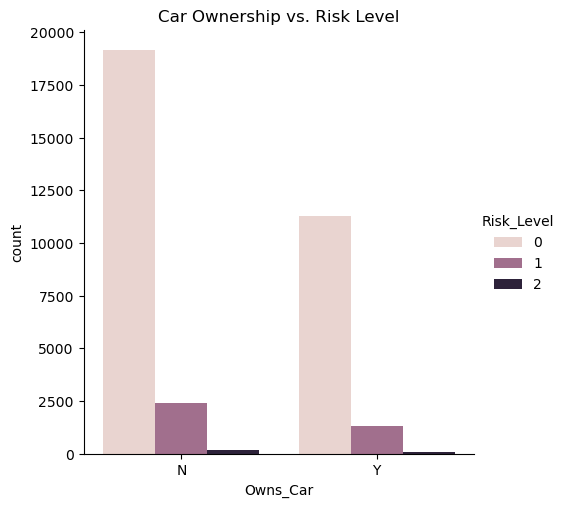

In [8]:
query = """
SELECT Owns_Car, Risk_Level, COUNT(*) as count
FROM clients
GROUP BY Owns_Car, Risk_Level
"""
car_vs_risk = pd.read_sql(query, conn)
display(car_vs_risk)
sns.catplot(x='Owns_Car', y='count', hue='Risk_Level', data=car_vs_risk, kind="bar")
plt.title("Car Ownership vs. Risk Level")
plt.show()


This analysis investigates the relationship between car ownership and credit risk classification. Across all risk levels, a larger number of clients do not own a car (Owns_Car = N). For example, among Good Clients (Risk_Level 0), 19,167 do not own a car, compared to 11,267 who do. This pattern holds for both Low Risk and High Risk groups. In the High Risk category (Risk_Level 2), there are almost twice as many clients without a car (182) compared to those with a car (94). These results suggest that not owning a car is slightly more prevalent among higher-risk clients, which could indicate an association between lack of car ownership and elevated credit risk. However, car ownership alone is not a definitive predictor, as both owners and non-owners are represented across all risk levels.



##### Question 5: Average Employment Duration by Risk Class

In [10]:
query = """
SELECT Risk_Level, AVG(Employment_Duration) as avg_employment_years
FROM clients
GROUP BY Risk_Level
"""
emp_years = pd.read_sql(query, conn)
display(emp_years)


,Risk_Level,avg_employment_years
0,0,7.249029
1,1,7.173505
2,2,6.077830


This analysis examines the average employment duration (in years) for clients in each credit risk category. Good Clients (Risk_Level 0) have, on average, the longest employment history at 7.25 years. Low Risk clients (Risk_Level 1) show a similar average employment duration of 7.17 years. High Risk clients (Risk_Level 2) have the shortest average employment history, with only 6.08 years. This suggests a potential link between employment stability and lower credit risk, as individuals with longer work tenures tend to be classified in safer risk groups. Nevertheless, while employment duration appears to be a contributing factor, it is not the sole determinant of risk, since overlaps exist between groups.



#### Question 6: Average Number of Children by Risk

In [11]:
query = """
SELECT Risk_Level, AVG(Children_Count) AS avg_children
FROM clients
GROUP BY Risk_Level
"""
children_stats = pd.read_sql(query, conn)
display(children_stats)

,Risk_Level,avg_children
0,0,0.385260
1,1,0.403738
2,2,0.315217


This analysis investigates the average number of children for clients in each credit risk class. Good Clients (Risk_Level 0) and Low Risk clients (Risk_Level 1) have, on average, close to 0.4 children per client, while High Risk clients (Risk_Level 2) have a slightly lower average at 0.32. The differences across risk classes are minimal, suggesting that the number of children does not substantially differentiate between credit risk categories in this dataset. Therefore, family size, at least as measured by the number of children, is unlikely to be a strong standalone predictor of credit risk.



##### Question 7: Percentage of High-Risk Clients Above Median Income

In [15]:
# Income median
income_median = df['Income'].median()

# Income Above Median
df['Income_Above_Median'] = (df['Income'] > income_median).astype(int)

# Procent High Risk
pct_above_median = 100 * df.loc[df['Risk_Level'] == 2, 'Income_Above_Median'].mean()
print(f"{pct_above_median:.2f}% of High Risk clients have income above the median.")


50.72% of High Risk clients have income above the median.


This analysis examines the proportion of clients classified as High Risk (Risk_Level 2) who have an income above the median for the dataset. The result indicates that 50.72% of individuals in the High Risk group have an income greater than the median value. This finding suggests that a substantial portion of clients identified as high risk are not necessarily low-income individuals. In other words, high credit risk is not exclusively associated with low income in this sample. Therefore, while income is an important factor in credit risk modeling, it does not act as a strict separator for the High Risk group, and other behavioral or demographic features may be more discriminative.



##### Question 8: Income Type Distribution Across Risk Levels


In [18]:
query = """
SELECT Income_Type, Risk_Level, COUNT(*) AS count
FROM clients
GROUP BY Income_Type, Risk_Level
ORDER BY Income_Type, Risk_Level
"""
income_type_dist = pd.read_sql(query, conn)
display(income_type_dist)


,Income_Type,Risk_Level,count
0,Commercial associate,0,6823
1,Commercial associate,1,910
2,Commercial associate,2,68
3,Pensioner,0,5420
4,Pensioner,1,560
5,Pensioner,2,69
6,State servant,0,2400
7,State servant,1,347
8,State servant,2,19
9,Student,0,10


This analysis summarizes the distribution of clients’ income types across different credit risk categories. The majority of clients classified as Low or High Risk (Risk_Level 1 and 2) are employed (‘Working’) or are ‘Commercial associates’, with ‘Pensioners’ and ‘State servants’ also represented in both categories. Interestingly, the number of ‘Students’ in any risk class is very low, and almost absent in the High Risk group. This suggests that income type alone does not exclusively determine risk, but certain types—such as ‘Working’ and ‘Commercial associate’—are more common among all risk groups, simply due to their higher base prevalence in the population. However, the relatively higher proportions of high-risk cases among ‘Pensioners’ and ‘Commercial associates’ compared to their overall group sizes could be indicative of specific financial vulnerabilities or risk profiles.



##### Question 9: Feature Means for High-Risk Clients


In [19]:
query = """
SELECT AVG(Age) AS avg_age, AVG(Account_Age) AS avg_account_age, AVG(Income) AS avg_income
FROM clients
WHERE Risk_Level = 2
"""
highrisk_stats = pd.read_sql(query, conn)
display(highrisk_stats)


,avg_age,avg_account_age,avg_income
0,45.537681,36.028986,171414.130435


This query reports the mean values for key features among clients classified as High Risk (Risk_Level = 2). The average age of high-risk clients is approximately 45.5 years, their average account age is about 36 months (3 years), and their average monthly income is 171,414.

These statistics suggest that high-risk clients in this dataset tend to be middle-aged individuals with moderately long credit histories. Despite their higher risk designation, their mean income is similar to the overall population median, indicating that high risk in this context is not strictly associated with lower income. Instead, risk is likely driven by a combination of behavioral factors, account history, and perhaps other demographic characteristics. These aggregated means provide a profile of the typical high-risk client and can inform targeted risk mitigation strategies.

##### Question 10: Distribution by Family Size and Risk

In [20]:
query = """
SELECT Family_Size, Risk_Level, COUNT(*) AS count
FROM clients
GROUP BY Family_Size, Risk_Level
ORDER BY Family_Size, Risk_Level
"""
fam_dist = pd.read_sql(query, conn)
display(fam_dist)


,Family_Size,Risk_Level,count
0,1.0,0,5934
1,1.0,1,719
2,1.0,2,68
3,2.0,0,16558
4,2.0,1,2020
5,2.0,2,151
6,3.0,0,5379
7,3.0,1,638
8,3.0,2,40
9,4.0,0,2563


This query analyzes the distribution of clients across different family sizes and risk levels. The majority of clients, regardless of risk, are found in families of size 2.0, followed by family sizes 1.0, 3.0, and 4.0. Within each family size, the vast majority of clients are classified as 'Good Client' (Risk_Level = 0), with the proportion of 'Low Risk' and 'High Risk' clients decreasing as family size increases.

For example, among families of size 2.0, there are 16,558 good clients compared to only 151 high-risk clients. The trend is similar for other family sizes. This distribution indicates that family size alone is not a strong indicator of credit risk, as the risk class proportions remain fairly consistent across family sizes. However, smaller family sizes (such as 1.0) show a slightly higher proportion of high-risk clients than larger families. This could suggest that single-person households face slightly higher credit risk, possibly due to lower shared financial responsibility or less financial cushioning.

##### Conclusion

The integration of SQL-driven analysis within the credit risk project has provided several tangible benefits. First, it enabled clear, interpretable answers to business-relevant questions—such as the distribution of risk classes, average client income, and key demographic relationships—that can be communicated directly to decision-makers. Second, SQL queries allowed for efficient aggregation and slicing of large datasets, revealing patterns and trends that might remain hidden in purely algorithmic approaches.

However, it is important to recognize the limitations of SQL as an analytical tool in complex predictive modeling. While SQL excels at aggregation, filtering, and grouping, it is less suitable for advanced statistical analysis, feature engineering, or machine learning, where procedural programming (e.g., in Python or R) offers greater flexibility. Additionally, SQL code can become cumbersome for multi-step, multi-table transformations, and may not easily integrate with version control or modular pipelines.

In summary, supplementing the credit risk workflow with SQL-based questions has enriched the exploratory analysis and improved the transparency and accessibility of results. Nevertheless, for end-to-end modeling and reproducibility, SQL is best viewed as a complementary tool—most effective when integrated with, but not replacing, modern data science programming practices.